In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

In [4]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [15]:
df.shape

(541909, 8)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [17]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [20]:
df.duplicated().sum()

np.int64(5268)

In [24]:
df.corr(numeric_only=True)

,Quantity,UnitPrice,CustomerID
Quantity,1.000000,-0.001235,-0.00360
UnitPrice,-0.001235,1.000000,-0.00456
CustomerID,-0.003600,-0.004560,1.00000


In [29]:
df['Total_Price']=df['Quantity']*df['UnitPrice']

In [30]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [31]:
df.corr(numeric_only=True)

,Quantity,UnitPrice,CustomerID,Total_Price
Quantity,1.000000,-0.001235,-0.003600,0.886681
UnitPrice,-0.001235,1.000000,-0.004560,-0.162029
CustomerID,-0.003600,-0.004560,1.000000,-0.002274
Total_Price,0.886681,-0.162029,-0.002274,1.000000


In [5]:
df = df.dropna(subset=["CustomerID"])

In [6]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [7]:
df = df[df["Quantity"] > 0]

In [8]:
df = df[df["UnitPrice"] > 0]

In [9]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [10]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [12]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [13]:
df["Country"].value_counts().head(10)

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

In [14]:
df["Description"].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1723
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1396
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
Name: count, dtype: int64

In [15]:
country_sales = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64

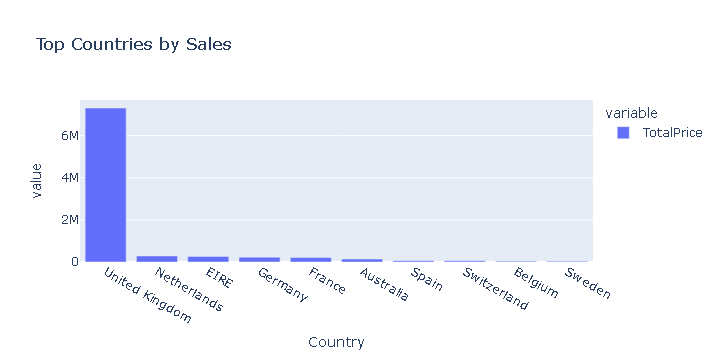

In [16]:
px.bar(
    country_sales,
    title="Top Countries by Sales"
)

In [17]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [18]:
rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "InvoiceNo": "nunique",

    "TotalPrice": "sum"

})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [19]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [20]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    wcss.append(model.inertia_)

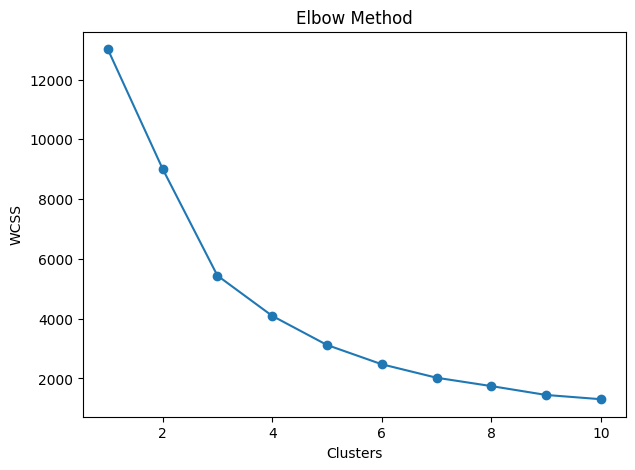

In [21]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [98]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

print(cluster_summary)

         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09


In [100]:
cluster_names = {
    0: "VIP Customers",
    1: "At-Risk Customers",
    2: "Loyal Customers",
    3: "New Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

In [101]:
rfm[["Recency", "Frequency", "Monetary", "Cluster", "Segment"]].head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,New Customers
12347.0,2,7,4310.00,0,VIP Customers
12348.0,75,4,1797.24,0,VIP Customers
12349.0,19,1,1757.55,0,VIP Customers
12350.0,310,1,334.40,1,At-Risk Customers


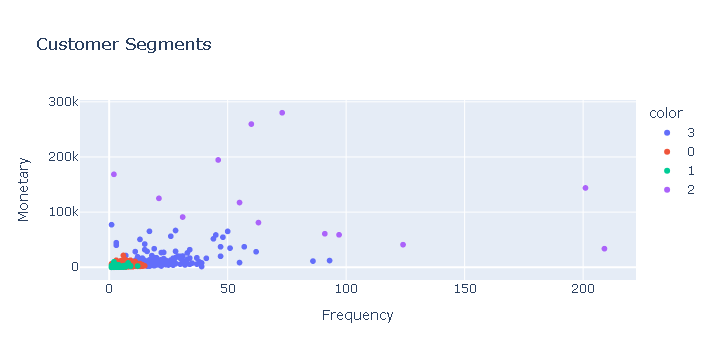

In [102]:
fig = px.scatter(
    rfm,
    x="Frequency",
    y="Monetary",
    color=rfm["Cluster"].astype(str),
    hover_data=["Recency"],
    title="Customer Segments"
)

fig.show()

**Predict**

In [103]:
new_customer = pd.DataFrame({
    "Recency": [15],
    "Frequency": [25],
    "Monetary": [12000]
})

In [104]:
new_customer_scaled = scaler.transform(new_customer)

In [107]:
cluster = kmeans.predict(new_customer_scaled)

print("Predicted Cluster :", cluster[0])
print("Customer Segment  :", cluster_names[cluster[0]])

Predicted Cluster : 3
Customer Segment  : New Customers


**RETENTION**

In [25]:
customer_dates = df.groupby("CustomerID").agg(
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max")
)

customer_dates.head()

,FirstPurchase,LastPurchase
CustomerID,,
12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00
12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00
12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00
12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00


In [26]:
customer_dates["DaysActive"] = (
    customer_dates["LastPurchase"] -
    customer_dates["FirstPurchase"]
).dt.days

customer_dates.head()

,FirstPurchase,LastPurchase,DaysActive
CustomerID,,,
12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,0
12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,365
12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,282
12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,0
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,0


In [27]:
customer_dates["Retained"] = (
    customer_dates["DaysActive"] >= 90
).astype(int)

customer_dates.head()

,FirstPurchase,LastPurchase,DaysActive,Retained
CustomerID,,,,
12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,0,0
12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,365,1
12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,282,1
12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,0,0
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,0,0


In [28]:
rfm = rfm.merge(
    customer_dates["Retained"],
    left_index=True,
    right_index=True
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Retained
CustomerID,,,,,
12346.0,326,1,77183.60,3,0
12347.0,2,7,4310.00,0,1
12348.0,75,4,1797.24,0,1
12349.0,19,1,1757.55,0,0
12350.0,310,1,334.40,1,0


In [29]:
X = rfm[["Recency", "Frequency", "Monetary"]]

y = rfm["Retained"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8387096774193549
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       430
           1       0.83      0.86      0.84       438

    accuracy                           0.84       868
   macro avg       0.84      0.84      0.84       868
weighted avg       0.84      0.84      0.84       868

[[351  79]
 [ 61 377]]


In [35]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
1  Frequency    0.413542
2   Monetary    0.354761
0    Recency    0.231698


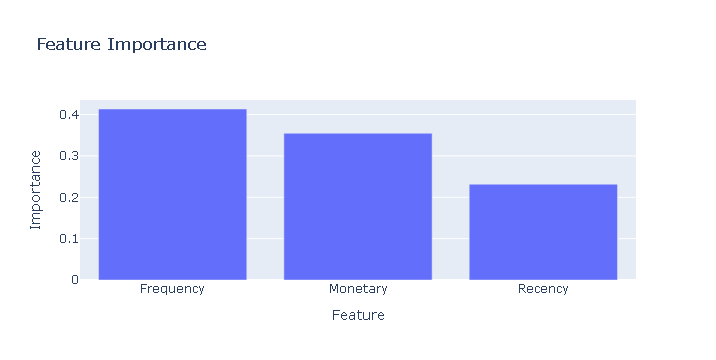

In [36]:
import plotly.express as px

fig = px.bar(
    importance,
    x="Feature",
    y="Importance",
    title="Feature Importance"
)

fig.show()

In [37]:
new_customer = [[20, 15, 2500]]

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

print(prediction)

[1]


C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [38]:
customer_features = df.groupby("CustomerID").agg(
    Monetary=("TotalPrice", "sum"),
    Frequency=("InvoiceNo", "nunique")
)

customer_features["AverageOrderValue"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

customer_features.head()


,Monetary,Frequency,AverageOrderValue
CustomerID,,,
12346.0,77183.60,1,77183.600000
12347.0,4310.00,7,615.714286
12348.0,1797.24,4,449.310000
12349.0,1757.55,1,1757.550000
12350.0,334.40,1,334.400000


In [39]:
customer_features["AverageQuantity"] = (
    df.groupby("CustomerID")["Quantity"].sum() /
    customer_features["Frequency"]
)

customer_features.head()

,Monetary,Frequency,AverageOrderValue,AverageQuantity
CustomerID,,,,
12346.0,77183.60,1,77183.600000,74215.000000
12347.0,4310.00,7,615.714286,351.142857
12348.0,1797.24,4,449.310000,585.250000
12349.0,1757.55,1,1757.550000,631.000000
12350.0,334.40,1,334.400000,197.000000


In [40]:
customer_features["UniqueProducts"] = (
    df.groupby("CustomerID")["StockCode"].nunique()
)

customer_features.head()

,Monetary,Frequency,AverageOrderValue,AverageQuantity,UniqueProducts
CustomerID,,,,,
12346.0,77183.60,1,77183.600000,74215.000000,1
12347.0,4310.00,7,615.714286,351.142857,103
12348.0,1797.24,4,449.310000,585.250000,22
12349.0,1757.55,1,1757.550000,631.000000,73
12350.0,334.40,1,334.400000,197.000000,17


In [41]:
customer_features["CountriesPurchased"] = (
    df.groupby("CustomerID")["Country"].nunique()
)

customer_features.head()

,Monetary,Frequency,AverageOrderValue,AverageQuantity,UniqueProducts,CountriesPurchased
CustomerID,,,,,,
12346.0,77183.60,1,77183.600000,74215.000000,1,1
12347.0,4310.00,7,615.714286,351.142857,103,1
12348.0,1797.24,4,449.310000,585.250000,22,1
12349.0,1757.55,1,1757.550000,631.000000,73,1
12350.0,334.40,1,334.400000,197.000000,17,1


In [43]:
df = df.sort_values(["CustomerID", "InvoiceDate"])

In [44]:
purchase_gap = (
    df.groupby("CustomerID")["InvoiceDate"]
      .diff()
      .dt.days
)

In [45]:
customer_features["DaysBetweenPurchases"] = (
    purchase_gap.groupby(df["CustomerID"]).mean()
)

customer_features.head()

,Monetary,Frequency,AverageOrderValue,AverageQuantity,UniqueProducts,CountriesPurchased,DaysBetweenPurchases
CustomerID,,,,,,,
12346.0,77183.60,1,77183.600000,74215.000000,1,1,NaN
12347.0,4310.00,7,615.714286,351.142857,103,1,2.0
12348.0,1797.24,4,449.310000,585.250000,22,1,9.4
12349.0,1757.55,1,1757.550000,631.000000,73,1,0.0
12350.0,334.40,1,334.400000,197.000000,17,1,0.0


In [46]:
customer_features["DaysBetweenPurchases"] = (
    customer_features["DaysBetweenPurchases"].fillna(0)
)

In [47]:
customer_features.head()

,Monetary,Frequency,AverageOrderValue,AverageQuantity,UniqueProducts,CountriesPurchased,DaysBetweenPurchases
CustomerID,,,,,,,
12346.0,77183.60,1,77183.600000,74215.000000,1,1,0.0
12347.0,4310.00,7,615.714286,351.142857,103,1,2.0
12348.0,1797.24,4,449.310000,585.250000,22,1,9.4
12349.0,1757.55,1,1757.550000,631.000000,73,1,0.0
12350.0,334.40,1,334.400000,197.000000,17,1,0.0


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(random_state=42),
    
    "KNN": KNeighborsClassifier(),
    
    "SVM": SVC(),
    
    "Naive Bayes": GaussianNB(),
    
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
}

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [55]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
6,XGBoost,0.855991,0.826722,0.904110,0.863686
4,SVM,0.852535,0.852273,0.856164,0.854214
3,KNN,0.845622,0.829004,0.874429,0.851111
2,Random Forest,0.835253,0.827051,0.851598,0.839145
1,Decision Tree,0.831797,0.842723,0.819635,0.831019
0,Logistic Regression,0.828341,0.877285,0.767123,0.818514
5,Naive Bayes,0.731567,0.939914,0.500000,0.652757


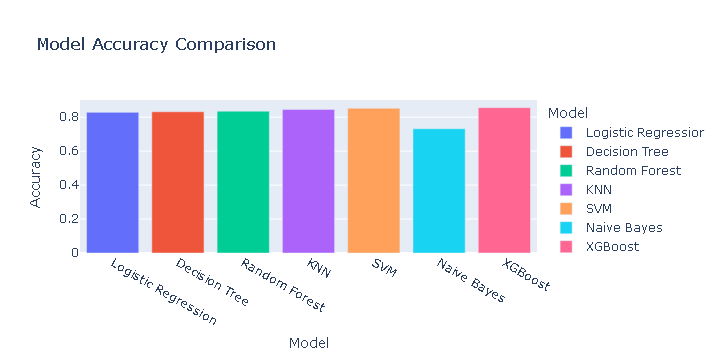

In [56]:
import plotly.express as px

fig = px.bar(
    results_df,
    x="Model",
    y="Accuracy",
    color="Model",
    title="Model Accuracy Comparison"
)

fig.show()

In [57]:
from sklearn.metrics import roc_auc_score

In [58]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Probability predictions
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
6,XGBoost,0.855991,0.826722,0.904110,0.863686,0.939941
4,SVM,0.852535,0.852273,0.856164,0.854214,0.937719
0,Logistic Regression,0.828341,0.877285,0.767123,0.818514,0.932415
2,Random Forest,0.835253,0.827051,0.851598,0.839145,0.924796
3,KNN,0.845622,0.829004,0.874429,0.851111,0.922611
5,Naive Bayes,0.731567,0.939914,0.500000,0.652757,0.868100
1,Decision Tree,0.831797,0.842723,0.819635,0.831019,0.831910


In [59]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

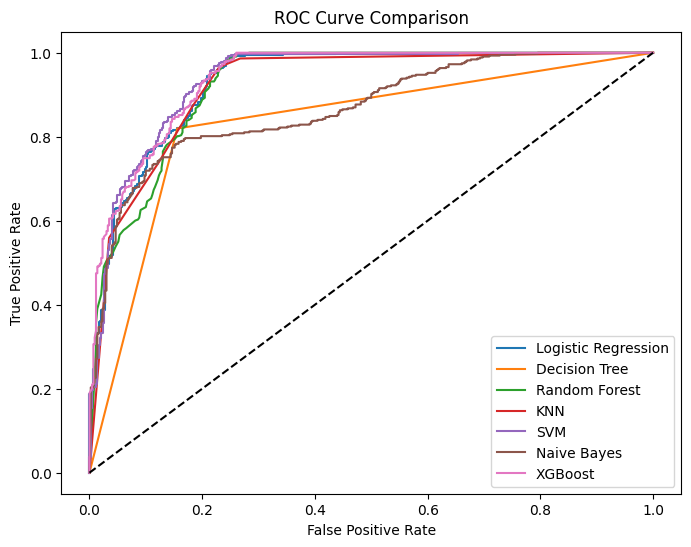

In [60]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [61]:
from sklearn.model_selection import cross_val_score

In [62]:
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df.sort_values("Mean CV Accuracy", ascending=False)

,Model,Mean CV Accuracy,Std
6,XGBoost,0.867680,0.007060
0,Logistic Regression,0.850854,0.003401
2,Random Forest,0.850388,0.007910
1,Decision Tree,0.822727,0.007942
3,KNN,0.772702,0.009961
4,SVM,0.766246,0.013583
5,Naive Bayes,0.740438,0.016592


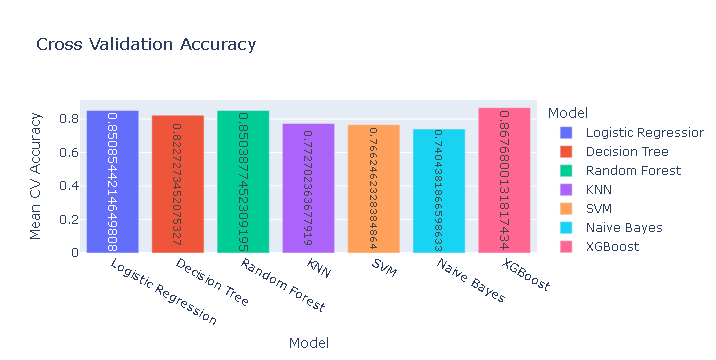

In [63]:
import plotly.express as px

fig = px.bar(
    cv_df,
    x="Model",
    y="Mean CV Accuracy",
    color="Model",
    text="Mean CV Accuracy",
    title="Cross Validation Accuracy"
)

fig.show()

In [64]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [65]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [66]:
param_grid = {

    'n_estimators': [100, 200, 300],

    'max_depth': [3, 5, 7],

    'learning_rate': [0.01, 0.1, 0.2],

    'subsample': [0.8, 1.0],

    'colsample_bytree': [0.8, 1.0]

}

In [67]:
grid_search = GridSearchCV(

    estimator=xgb,

    param_grid=param_grid,

    scoring='accuracy',

    cv=5,

    n_jobs=-1,

    verbose=2

)

In [68]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [69]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [70]:
best_xgb = grid_search.best_estimator_


In [71]:
y_pred = best_xgb.predict(X_test)

In [72]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

roc_auc = roc_auc_score(
    y_test,
    best_xgb.predict_proba(X_test)[:,1]
)

print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)
print("ROC-AUC :",roc_auc)

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy : 0.8525345622119815
Precision : 0.8137651821862348
Recall : 0.9178082191780822
F1 Score : 0.8626609442060086
ROC-AUC : 0.9408622703621111
[[338  92]
 [ 36 402]]
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       430
           1       0.81      0.92      0.86       438

    accuracy                           0.85       868
   macro avg       0.86      0.85      0.85       868
weighted avg       0.86      0.85      0.85       868



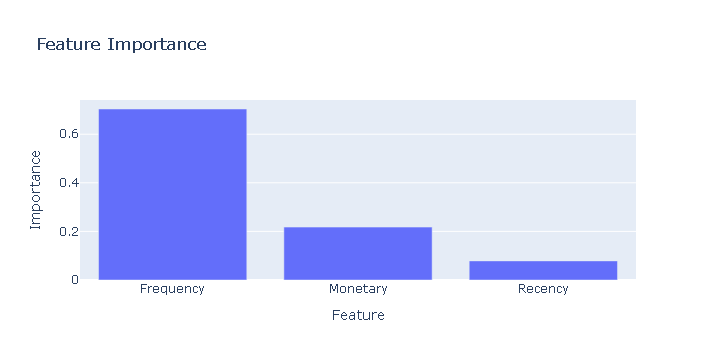

In [73]:
import pandas as pd
import plotly.express as px

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_xgb.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

fig = px.bar(
    importance,
    x="Feature",
    y="Importance",
    title="Feature Importance"
)

fig.show()

**RandomSearchCV**

In [82]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [83]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [84]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.05,0.1,0.2],

    "subsample":[0.8,1],

    "colsample_bytree":[0.8,1],

    "min_child_weight":[1,3,5]
}

In [85]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=20,

    scoring="f1",

    cv=5,

    random_state=42,

    verbose=2,

    n_jobs=-1

)

In [86]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [87]:
print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [88]:
{
 'subsample': 1,
 'n_estimators': 300,
 'min_child_weight': 1,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8
}

{'subsample': 1,
 'n_estimators': 300,
 'min_child_weight': 1,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [89]:
print(random_search.best_score_)

0.8784196181064446


In [90]:
best_xgb = random_search.best_estimator_

In [91]:
y_pred = best_xgb.predict(X_test)

y_prob = best_xgb.predict_proba(X_test)[:,1]

In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC :", roc_auc_score(y_test,y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report")
print(classification_report(y_test,y_pred))

Accuracy : 0.8548387096774194
Precision : 0.8183673469387756
Recall : 0.9155251141552512
F1 Score : 0.8642241379310345
ROC AUC : 0.9390862270362111

Confusion Matrix
[[341  89]
 [ 37 401]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       430
           1       0.82      0.92      0.86       438

    accuracy                           0.85       868
   macro avg       0.86      0.85      0.85       868
weighted avg       0.86      0.85      0.85       868



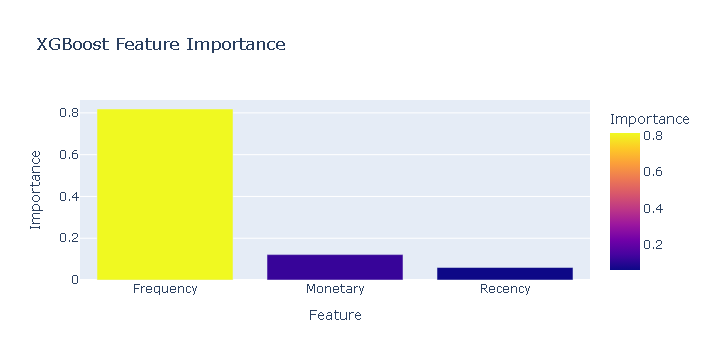

In [93]:
import pandas as pd
import plotly.express as px

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

fig = px.bar(
    importance,
    x="Feature",
    y="Importance",
    color="Importance",
    title="XGBoost Feature Importance"
)

fig.show()

In [113]:
# New customer
new_customer = pd.DataFrame({
    "Recency": [20],
    "Frequency": [15],
    "Monetary": [8000]
})

# -------- Customer Segmentation --------

new_customer_scaled = scaler.transform(new_customer)

cluster = kmeans.predict(new_customer_scaled)[0]

cluster_names = {
    0: "VIP Customer",
    1: "Loyal Customer",
    2: "At-Risk Customer",
    3: "New Customer"
}

segment = cluster_names[cluster]

# -------- Customer Retention --------

retention = best_xgb.predict(new_customer)[0]

retention_probability = best_xgb.predict_proba(new_customer)[0][1]

retention_status = (
    "Likely to be Retained"
    if retention == 1
    else "Likely to Churn"
)

# -------- Final Output --------

print("=" * 50)
print("CUSTOMER ANALYSIS REPORT")
print("=" * 50)

print(f"Customer Segment      : {segment}")
print(f"Retention Status      : {retention_status}")
print(f"Retention Probability : {retention_probability:.2%}")

print("=" * 50)

CUSTOMER ANALYSIS REPORT
Customer Segment      : New Customer
Retention Status      : Likely to Churn
Retention Probability : 36.84%


In [114]:
import joblib

joblib.dump(best_xgb, "customer_retention_xgboost.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [115]:
pip install streamlit


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [118]:
import os
print(os.getcwd())

C:\Users\idev9\ML
